# Gaussian Process and Uncertainty for Bike-Sharing Demand Forecasting
### By Alper Kaya and Khanh Minh Dinh

# Introduction

Bike-sharing systems have changed the way people use bicycles in cities, as they provide eco-friendly alternatives to the use of cars. Capital Bikeshare, an automated bike-sharing program operational in the USA, gathered a large amount of hourly data regarding bike sharing, which goes in accordance with the day-to-day and hour-to-hour variability in user demand due to environmental and time-related factors. The large volume of data collected creates difficulties for administrators in predicting bike sharing and calculating the logistics.

Different factors, such as weather and peak commuting activity, might result in known higher demands but still experience high level of variability. In particular, while known demands may easily be forecasted in commonly available forecasting tools, GPs can be a great alternative due to factors such as GPs being non-parametric and reducing the challenges of variability in forecasting associated with other models. Furthermore, they naturally provide uncertainty estimates for the generated predictions, which can assist operators in decision-making.    

This paper examines to what degree of accuracy the Gaussian Processes method can be used to forecast the number of bike share demand during the day hours (7-19) when there are multiple sources of uncertainties and potential noise. The UCI Bike Sharing dataset, which has 17,389 hourly records collected at all stations across Washington D.C between 2011 and 2012, was used for the aformentioned research goal. For this project, we split the dataset into 2011 for training and 2012 for testing. Furthermore, we filtered the dataset to only train and test only on observations between 7AM-7PM. The split in time in this paper will be solely to allow it to test its results over a whole year to capture uncertainties in demand forecasts, and use this to forecast the bike rentals for 2012 during daytime when rentals are the highest.

The dataset was retrieved from https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset. 

Below is a table that lists the variables’ names, their descriptions, types, and units of measurement:



In [ ]:
#Loading the packages
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

#Creating the data dictionary
rows = [
    {"Variable": "instant", "Description": "record index", "Type": "integer", "Unit / Scale": "-"},
    {"Variable": "dteday", "Description": "date", "Type": "date", "Unit / Scale": "-"},
    {"Variable": "season", "Description": "1:spring, 2:summer, 3:autumn, 4:winter", "Type": "categorical", "Unit / Scale": "1-4"},
    {"Variable": "yr", "Description": "year (0: 2011, 1: 2012)", "Type": "categorical", "Unit / Scale": "0-1"},
    {"Variable": "mnth", "Description": "month (1 to 12)", "Type": "categorical", "Unit / Scale": "1-12"},
    {"Variable": "hr", "Description": "hour (0 to 23)", "Type": "categorical", "Unit / Scale": "0-23"},
    {"Variable": "holiday", "Description": "weather day is holiday or not", "Type": "binary", "Unit / Scale": "0-1"},
    {"Variable": "weekday", "Description": "day of the week", "Type": "categorical", "Unit / Scale": "0-6"},
    {"Variable": "workingday", "Description": "if day is neither weekend nor holiday is 1, otherwise is 0", "Type": "binary", "Unit / Scale": "0-1"},
    {"Variable": "weathersit", "Description": "1: Clear; 2: Mist/Cloudy; 3: Light Snow/Rain; 4: Heavy Rain", "Type": "categorical", "Unit / Scale": "1-4"},
    {"Variable": "temp", "Description": "Normalized temperature in Celsius", "Type": "continuous", "Unit / Scale": "0-1"},
    {"Variable": "atemp", "Description": "Normalized feeling temperature in Celsius", "Type": "continuous", "Unit / Scale": "0-1"},
    {"Variable": "hum", "Description": "Normalized humidity", "Type": "continuous", "Unit / Scale": "0-1"},
    {"Variable": "windspeed", "Description": "Normalized wind speed", "Type": "continuous", "Unit / Scale": "0-1"},
    {"Variable": "casual", "Description": "count of casual users", "Type": "integer", "Unit / Scale": "count"},
    {"Variable": "registered", "Description": "count of registered users", "Type": "integer", "Unit / Scale": "count"},
    {"Variable": "cnt", "Description": "count of total rental bikes (casual + registered)", "Type": "integer", "Unit / Scale": "count"}
]

data_dict = pd.DataFrame(rows)
data_dict


,Variable,Description,Type,Unit / Scale
0,instant,record index,integer,-
1,dteday,date,date,-
2,season,"1:spring, 2:summer, 3:autumn, 4:winter",categorical,1-4
3,yr,"year (0: 2011, 1: 2012)",categorical,0-1
4,mnth,month (1 to 12),categorical,1-12
5,hr,hour (0 to 23),categorical,0-23
6,holiday,weather day is holiday or not,binary,0-1
7,weekday,day of the week,categorical,0-6
8,workingday,"if day is neither weekend nor holiday is 1, ot...",binary,0-1
9,weathersit,1: Clear; 2: Mist/Cloudy; 3: Light Snow/Rain; ...,categorical,1-4


# Literature Review

Gaussian Process (GP) regression is a type of kernel-based method where a positive semidefinite kernel defines the similarity between two inputs and, by implication, creates a rich nonlinear feature space that permits very flexible regression without the need for any explicit feature construction [2]. GP regression is considered the Bayesian version of kernel ridge regression, where the kernel becomes the covariance function of a prior distribution over functions. GP gives rise to closed-form Gaussian posterior predictive distributions of both means and variances [2]. In a Bayesian framework, the learning process corresponds to updating the prior information of the parameters (or functions) to the posterior and making predictions for new inputs based on the posterior predictive distribution. The posterior predictive distribution naturally provides calibrated prediction intervals and reduces the likelihood of overfitting when compared to pure maximum-likelihood estimates, particularly in the presence of noise or in a sparsely populated data environment [2].

Compared to traditional parametric and basic nonparametric regression techniques, which typically only focus on estimating the conditional mean of the target variable, GPs are capable of providing direct estimates of uncertainty in the estimated function, and as such, they produce an increasing amount of predictive variance as you move away from the observed data [1, 2].

Gaussian Process Models, therefore, could be suitable for forecasting hourly bicycle rental demand [3], where the model is trained on historical data to predict future outcomes (e.g., the year 2012) while also providing uncertainty. This approach captures the complex, nonlinear influences of weather and temporal patterns while providing a formal measure of predictive uncertainty. This might allow for more informed decision-making, such as implementing larger safety margins in bike offerings when the model indicates low confidence in its own predictions [2].

While Gaussian Process Models have a lot of advantages, the primary bottleneck is computational complexity. The reason for that is that training the model involves inverting a covariance matrix, which has a cost of $O(n^3)$, where $n$ is the number of data points. This makes standard GPs impractical for very large datasets [2].

# Research Question and Methodology

## Research Question

Is it feasible to use Gaussian Process regression to forecast daytime bike rental demand from a time-series dataset and also quantifying weather-dependent uncertainty and rental volatility?

## Methodology:

This project began with a preparation step where we looked at the underlying data. We did not find any missing values in the dataset. The analysis focused only on daytime hours, from 7 AM to 7 PM. This reduced the dataset to 9,466 observations to capture peak rental times and lower the computational load since performing Gaussian Process on too many observations can lead to long running times.

The original four-category weather variable was transformed into a binary weather condition indicator. Clear weather matched with weather category 1, while wet weather included categories 2, 3, and 4, which represented mist, light rain or snow, and heavy rain, snow. This binary classification made it easier to compare predictive uncertainty across different weather conditions.

To deal with multicollinearity, highly correlated variables were removed. Specifically, feelliketemp, which had a 0.98 correlation with temperature, season with an 0.830 correlation with month, and the counts of casual and registered users were dropped since they were part of the total variable. Cyclic hour features, using sine and cosine transformations, were created to accurately represent the hour of the day. The target variable was log-transformed to stabilize variance and improve model performance.

Next, Gaussian Process regression was chosen for several key reasons related to bike-sharing demand forecasting. Unlike traditional regression methods that provide only point estimates, GPs offer a Bayesian framework that gives both predictions and quantified uncertainty estimates. This feature is especially useful for operators who need to understand not just expected demand, but also the reliability of their forecasts.

The non-parametric nature of GPs enables them to capture complex, nonlinear relationships between weather, time, and bike rental demand without needing predefined functional forms. Most importantly, GPs give calibrated uncertainty estimates that increase in areas with sparse data or high noise. During bad weather, demand tends to be more unpredictable, allowing GPs to capture this through their uncertainty quantification.

The kernel function describes how the GP generalises from observed data to unseen data points. A composite kernel was created by combining three components. The Constant Kernel (C), which scales the overall output variance and indicates signal strength, was used by having the bounds 1e-3 and 1e3, allowing the model to learn the right level of variation in rental counts. Furthermore, the Radial Basis Function (RBF kernel) was used. This kernel assumes that points close together in the input space should have similar outputs, with similarity fading as distance grows. The lengthscale parameter, with bounds of 1e-2 to 1e2, controls this decay rate. The RBF was chosen because bike rental demand shows smooth patterns over time and in relation to weather, rather than sudden changes. Furthermore, it is a common kernel used for Gaussian, and due to computational limitations, we were not able to test several kernels to find the best one.    

Additionally, we used the  White Kernel which gives models observation noise and measurement error. The noise level bounds of 1e-5 to 1e1 account for randomness in rentals and help avoid overfitting and stabilise numerical computations. The composite kernel structure was optimized using maximum likelihood estimation during training with two optimizer restarts. This kernel combination balances flexibility and smoothness, allowing the GP to provide accurate predictions and properly quantify uncertainty across various weather conditions.

The dataset was divided by year and filtered by time (7AM-7PM), with data from 2011 (4,727 samples) used for training and 2012 data (4,739 samples) set aside for testing. Features were standardized with a StandardScaler to ensure comparable scales across input variables. The model was trained with hyperparameter optimization to find the best kernel parameters.

Finally, model performance was evaluated using Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared metrics on the 2012 test set. Additionally, predictions were converted back from log-scale to the original scale using the exponential minus one function for better interpretability.


# Results and Discussion

## Data-Preperation and Analysis

Firstly, the data set was loaded onto the notebook with blanks, 'NA', 'NaN and 'Null' treated as missing values. Some columns' names have been changed for better understanding as below:

In [3]:
# Loading the datasets
hour = pd.read_csv('hour.csv', na_values=['', 'NA', 'NaN', 'NULL'])

# Changing columns' names for better understanding
hour.rename(columns={'dteday': 'date', 'yr': 'year', 'mnth': 'month', 'hr': 'hour', 'weathersit': 'weather', 'atemp': 'feel_like_temp', 'hum': 'humidity', 'cnt': 'total' }, inplace=True)

print(hour.head(10))

   instant        date  season  year  month  hour  holiday  weekday  \
0        1  2011-01-01       1     0      1     0        0        6   
1        2  2011-01-01       1     0      1     1        0        6   
2        3  2011-01-01       1     0      1     2        0        6   
3        4  2011-01-01       1     0      1     3        0        6   
4        5  2011-01-01       1     0      1     4        0        6   
5        6  2011-01-01       1     0      1     5        0        6   
6        7  2011-01-01       1     0      1     6        0        6   
7        8  2011-01-01       1     0      1     7        0        6   
8        9  2011-01-01       1     0      1     8        0        6   
9       10  2011-01-01       1     0      1     9        0        6   

   workingday  weather  temp  feel_like_temp  humidity  windspeed  casual  \
0           0        1  0.24          0.2879      0.81     0.0000       3   
1           0        1  0.22          0.2727      0.80     0.000

We then look for the missing values and remove them. The result below shows that there is no missing value in the data set in use. The information about the features of the data set was also summarized below:

In [4]:
hour.info()

missing_hour  = hour.isnull().sum()

missing = pd.DataFrame({
    'missing_hour': missing_hour
})

print(missing)

print("There is no missing value in the data set.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   instant         17379 non-null  int64  
 1   date            17379 non-null  object 
 2   season          17379 non-null  int64  
 3   year            17379 non-null  int64  
 4   month           17379 non-null  int64  
 5   hour            17379 non-null  int64  
 6   holiday         17379 non-null  int64  
 7   weekday         17379 non-null  int64  
 8   workingday      17379 non-null  int64  
 9   weather         17379 non-null  int64  
 10  temp            17379 non-null  float64
 11  feel_like_temp  17379 non-null  float64
 12  humidity        17379 non-null  float64
 13  windspeed       17379 non-null  float64
 14  casual          17379 non-null  int64  
 15  registered      17379 non-null  int64  
 16  total           17379 non-null  int64  
dtypes: float64(4), int64(12), objec

Subsequently, a data validation was performed to verify the integrity and ensure all variables fell within expected ranges. The validation confirmed that the total rental count was correctly calculated as the sum of 'casual' and 'registered' users, with a maximum absolute difference of zero. Furthermore, categorical variables were inspected for their distinct values: season contained four categories (1-4 representing spring through winter), year had two values (0 for 2011, 1 for 2012), month ranged from 1 to 12, hour spanned 0 to 23, and weather included four categories (1-4 representing clear to heavy rain conditions). Additionally, numeric ranges were verified for all continuous variables. Temperature, feel-like temperature, humidity, and windspeed were all normalized between 0 and 1 as expected from the dataset documentation. This validation step confirmed that all displayed data were accurate and consistent with the dataset specifications, ensuring no data entry errors or encoding issues were present before proceeding with feature engineering and modeling.

In [5]:
# Checking the accuracy of displayed information

max_diff = (hour["total"] - (hour["casual"] + (hour["registered"]))).abs().max()
print(max_diff)

print("season unique:", sorted(hour["season"].unique()))
print("year unique:", sorted(hour["year"].unique()))
print("month unique:", sorted(hour["month"].unique()))
print("hour unique:", sorted(hour["hour"].unique()))
print("weather unique:", sorted(hour["weather"].unique()))

for col in ["month", "hour"]:
    print(col, "min:", hour[col].min(), "max:", hour[col].max())

for col in ["temp", "feel_like_temp", "humidity", "windspeed"]:
    print(col, "min:", hour[col].min(), "max:", hour[col].max())

print("All data displayed are correct.")

0
season unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
year unique: [np.int64(0), np.int64(1)]
month unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
hour unique: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
weather unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
month min: 1 max: 12
hour min: 0 max: 23
temp min: 0.02 max: 1.0
feel_like_temp min: 0.0 max: 1.0
humidity min: 0.0 max: 1.0
windspeed min: 0.0 max: 0.8507
All data displayed are correct.


Since in this project, two weather conditions are taken into account, namely "clear" and "wet", the original four‑category "weather" variable was collapsed into a binary "weather" condition indicator. The “clear” condition corresponds to weather = 1 (clear, few clouds, partly cloudy), while the “wet” condition combines weather = 2, 3, 4 (mist, light rain/snow, and heavy rain/snow/fog), representing misty or rainy conditions.

In [6]:
# Create weather_regime: "clear" vs "wet" (2, 3, 4 together)
hour["weather_condition"] = np.where(hour["weather"] == 1, "clear", "wet")

print("Two weather conditions: ")
print(hour["weather_condition"].value_counts())


Two weather conditions: 
weather_condition
clear    11413
wet       5966
Name: count, dtype: int64


In this step, the first column "instant' will be dropped as it does not carry any information and is irrelevant to the analysis. Subsequently, a heatmap will be created to illustrate the correlations between variables in data set. Although the Gaussian Process is perfectly able to handle correlated input variables, checking correlations is still useful for removing highly correlated variable which are redundant.

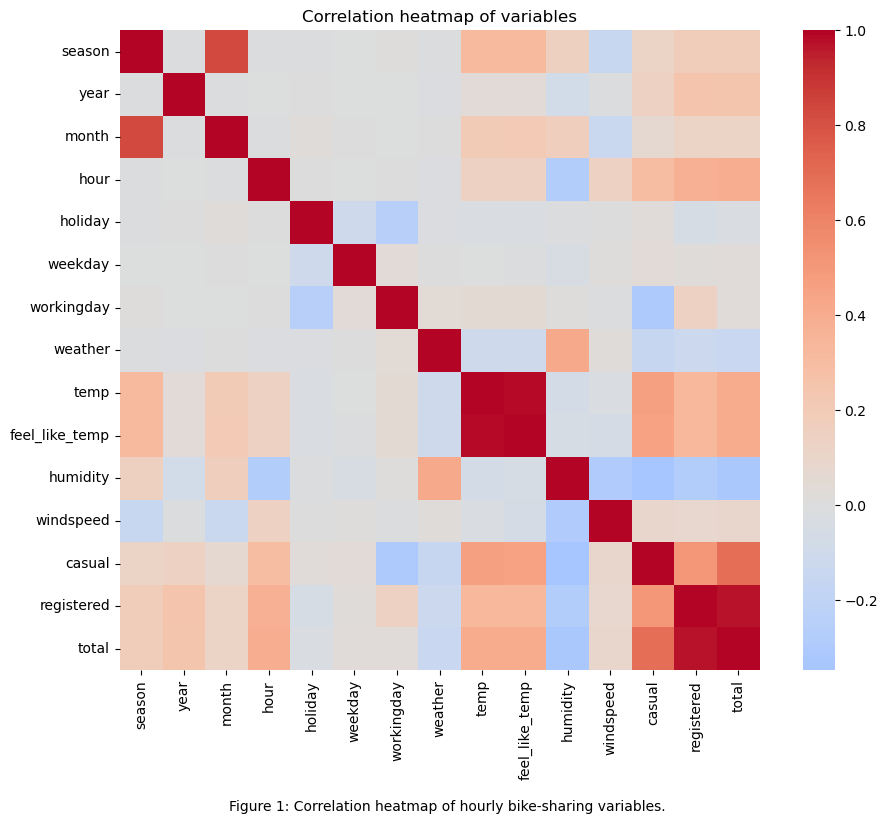

In [ ]:
#Dropping unnecessary columns for correlation analysis
hour = hour.drop(columns=["instant"])

# Compute correlation matrix (numeric columns only)
corr = hour.corr(numeric_only=True)

#Creating the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True
)
plt.title("Correlation heatmap of variables")

plt.figtext(
    0.5,
    -0.02,
    "Figure 1: Correlation heatmap of hourly bike-sharing variables.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

In [8]:
# Correlation matrix (numeric columns only)
corr = hour.corr(numeric_only=True)

# Keep only upper triangle (unique pairs), drop diagonal
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Convert to long format and filter by threshold
threshold = 0.60
high_corr = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "var_1", "level_1": "var_2", 0: "corr"})
)

high_corr["abs_corr"] = high_corr["corr"].abs()
high_corr = high_corr[high_corr["abs_corr"] >= threshold].sort_values("abs_corr", ascending=False)

high_corr


,var_1,var_2,corr,abs_corr
84,temp,feel_like_temp,0.987672,0.987672
104,registered,total,0.972151,0.972151
1,season,month,0.830386,0.830386
103,casual,total,0.694564,0.694564


According to the heat map and the table above, "temp" and "feel_like_temp" are highly correlated (which is understandable since the feel-like temperatures in real life usually does not deviate too much from the actual temperatures and they tend to move in the same direction). Similarly, high correlation is also witnessed between "season" and "month" due to the fact that seasons are combinations of months. Lastly, as "total" is a sum of "casual" and "registered", it is to some particular extent correlated to both of them and in this case, it is highly correlated to "registered". Therefore, although Gaussian Process Regression is able to deal with highly correlated variables, "feel_like_temp", "season", "registered" and "casual" columns will be dropped to alleviate the computational burden.

In [9]:
hour = hour.drop(columns=["feel_like_temp", "season", "registered", "casual"], errors='ignore')

To start off the analysis, a line chart which displays the demand for bike rentals in both years was sketched below. Apparently, the company witnessed an increase in demand in 2012 compared to 2011 (with an increase of 50-60% throughout all the months). This might possibly lead to issues in the later stages of this research since the target's variables mean increases outside of the expected range of the training dataset.

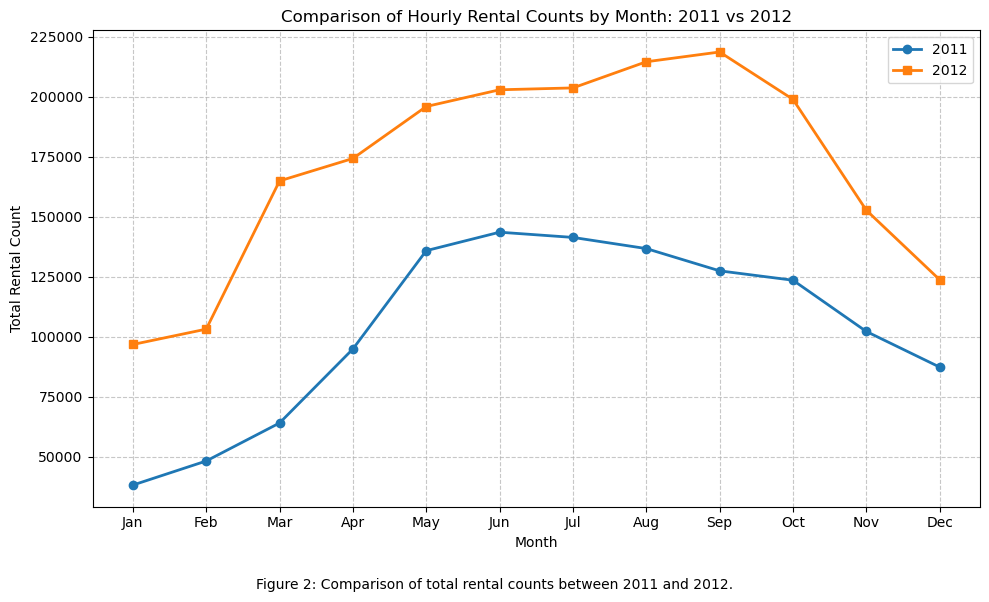

In [38]:
# Map yr (0, 1) to the actual years (2011, 2012)
hour['year_label'] = hour['year'].map({0: 2011, 1: 2012})

# Aggregate rental counts by year and month
monthly_counts = hour.groupby(['year_label', 'month'])['total'].sum().reset_index()

pivot_df = monthly_counts.pivot(index='month', columns='year_label', values='total')

# Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(pivot_df.index, pivot_df[2011], marker='o', label='2011', linewidth=2)
plt.plot(pivot_df.index, pivot_df[2012], marker='s', label='2012', linewidth=2)

# Chart formatting
plt.title('Comparison of Hourly Rental Counts by Month: 2011 vs 2012')
plt.xlabel('Month')
plt.ylabel('Total Rental Count')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

caption = "Figure 2: Comparison of total rental counts between 2011 and 2012."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('rental_comparison_2011_2012.png')

In the last step of data preparation, in order to make the data usable for a real-time Gaussian Process Regression, we have to build a real time index, encode hour-of-day correctly, and take the logarithm of the values in the "total" column. The dataset was filtered to focus exclusively on daytime hours (7 AM to 7 PM), reducing the original 17,379 observations to 9,466 samples. This filtering captured peak rental periods while excluding nighttime hours with minimal activity.

In [18]:
# Filter for hours 7 AM to 19 PM (hours 7-19)
hour_filtered = hour[(hour['hour'] >= 7) & (hour['hour'] <= 19)]

print("Original dataset shape:", hour.shape)
print("Filtered dataset shape:", hour_filtered.shape)


Original dataset shape: (17379, 14)
Filtered dataset shape: (9466, 14)


To properly encode the cyclical nature of time, the hour variable was transformed using sine and cosine functions. This cyclic encoding ensures the model recognizes that hour 23 is close to hour 0, preventing artificial discontinuities in temporal patterns.

The final feature set comprised eight variables: temperature, humidity, windspeed, hour_sin, hour_cos, workingday, weather, and month. Notably absent were the highly correlated variables (feel-like temperature, season, casual, and registered users) that were removed during the correlation analysis phase. The target variable (total bike rentals) was log-transformed using log1p to stabilize variance and improve model performance.

The data was split temporally rather than randomly to reflect real-world forecasting scenarios. All 2011 data (year=0) served as the training set with 4,727 samples, while 2012 data (year=1) formed the test set with 4,739 samples. This temporal split ensures the model is evaluated on genuinely unseen future data.

Finally, features were standardized using StandardScaler to ensure all variables operated on comparable scales. The scaler was fitted only on training data and then applied to test data to prevent data leakage.

In [19]:
hour_filtered = hour_filtered.copy()

# Add cyclic hour features safely
hour_filtered.loc[:, 'hour_sin'] = np.sin(2 * np.pi * hour_filtered['hour'] / 24)
hour_filtered.loc[:, 'hour_cos'] = np.cos(2 * np.pi * hour_filtered['hour'] / 24)

# Select features (using your renamed columns)
feature_cols = ['temp', 'humidity', 'windspeed', 'hour_sin', 'hour_cos',
                'workingday', 'weather', 'month']
X = hour_filtered[feature_cols].values
y = np.log1p(hour_filtered['total'].values) # renamed target

# Split by year: train year=0, test year=1
train_mask = hour_filtered['year'] == 0
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set (year=0): {X_train.shape[0]} samples")
print(f"Test set (year=1): {X_test.shape[0]} samples")

Train set (year=0): 4727 samples
Test set (year=1): 4739 samples


## Training and Evaluation

A Gaussian Process Regressor was initialized with a composite kernel combining a Constant kernel, RBF kernel, and White kernel to capture signal variance, smooth patterns, and observation noise respectively. The model was configured with 2 optimizer restarts to avoid local minima during hyperparameter optimization, an alpha parameter of 1e-10 for numerical stability, and normalized target values for improved performance.

The GP was trained on the standardized 2011 training data (filtered by daytime hours), with the kernel hyperparameters automatically optimized via maximum likelihood estimation. After training, the optimized kernel parameters were stored, reflecting the learned lengthscale (characteristic distance of correlation), signal variance, and noise level that best explained the bike rental patterns in the data. This  tuning ensures the model adapts to the specific characteristics of the bike-sharing demand rather than relying on arbitrary parameter choices.

In [20]:
# Define kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + \
         WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

# Initialize GP
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=2,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)

# Fit model
gp.fit(X_train_scaled, y_train)

print(f"Optimized kernel: {gp.kernel_}")


Optimized kernel: 1.87**2 * RBF(length_scale=1.96) + WhiteKernel(noise_level=0.0996)


The optimized kernel reveals that the model learned a signal variance of approximately 3.5 (1.87^2), a lengthscale of 1.96 indicating moderate smoothness in demand patterns across standardized features, and a noise level of 0.0996 representing relatively low observation noise.

Next, we have the trained GP model generated predictions on the 2012 test set, returning both mean predictions and standard deviations representing uncertainty. Predictions were transformed back from log-space to the original scale using the expm1 function for more precise inverse transformation. 95% confidence intervals were constructed by adding and subtracting 1.96 times the standard deviation from the mean predictions before back-transformation.

Then, the model performance was assessed using three metrics on the original scale: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R-squared. These metrics quantified the accuracy of point predictions and the proportion of variance explained by the model.

In [54]:
# 1. Predict with uncertainty for both training and test sets
y_train_pred_log, y_std_train = gp.predict(X_train_scaled, return_std=True)
y_test_pred_log, y_std_test = gp.predict(X_test_scaled, return_std=True)

# 2. Transform back from log scale using expm1
y_train_pred_original = np.expm1(y_train_pred_log)
y_train_original = np.expm1(y_train)

y_test_pred_original = np.expm1(y_test_pred_log)
y_test_original = np.expm1(y_test)

# 3. 95% confidence intervals (transformed to original scale)
y_lower = np.expm1(y_test_pred_log - 1.96 * y_std_test)
y_upper = np.expm1(y_test_pred_log + 1.96 * y_std_test)

# 4. Evaluate Metrics
train_rmse = np.sqrt(mean_squared_error(y_train_original, y_train_pred_original))
train_mae = mean_absolute_error(y_train_original, y_train_pred_original)
train_r2 = r2_score(y_train_original, y_train_pred_original)

test_rmse = np.sqrt(mean_squared_error(y_test_original, y_test_pred_original))
test_mae = mean_absolute_error(y_test_original, y_test_pred_original)
test_r2 = r2_score(y_test_original, y_test_pred_original)

# 5.  All Metrics 
print(f"Training Metrics:")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")
print(f"Train R²: {train_r2:.3f}")

print(f"\nTest Metrics:")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")
print(f"Test R²: {test_r2:.3f}")

# 6. Uncertainty Analysis by weather Training and Test
weather_train = hour_filtered[hour_filtered['year'] == 0]['weather'].values
weather_test = hour_filtered[hour_filtered['year'] == 1]['weather'].values

if len(weather_train) == len(y_std_train):
    train_clear_mask = (weather_train == 1)
    train_wet_mask = (weather_train > 1)
    print(f"\nTraining Confidence Analysis (Log-Scale Std):")
    print(f"Clear weather - Train Mean uncertainty (std): {y_std_train[train_clear_mask].mean():.3f}")
    print(f"Wet weather - Train Mean uncertainty (std): {y_std_train[train_wet_mask].mean():.3f}")

if len(weather_test) == len(y_std_test):
    test_clear_mask = (weather_test == 1)
    test_wet_mask = (weather_test > 1)
    print(f"\nTest Confidence Analysis (Log-Scale Std):")
    print(f"Clear weather - Test Mean uncertainty (std): {y_std_test[test_clear_mask].mean():.3f}")
    print(f"Wet weather - Test Mean uncertainty (std): {y_std_test[test_wet_mask].mean():.3f}")

Training Metrics:
Train RMSE: 40.83
Train MAE: 27.60
Train R²: 0.908

Test Metrics:
Test RMSE: 169.96
Test MAE: 140.93
Test R²: 0.284

Training Confidence Analysis (Log-Scale Std):
Clear weather - Train Mean uncertainty (std): 0.263
Wet weather - Train Mean uncertainty (std): 0.273

Test Confidence Analysis (Log-Scale Std):
Clear weather - Test Mean uncertainty (std): 0.271
Wet weather - Test Mean uncertainty (std): 0.305


The model demonstrated good accuracy on the 2011 dataset during training, achieving an RMSE of 40.83, an MAE of 27.60, and an $R^2$ of 0.908.
However, on the test set, the model achieved an RMSE of 169.96 bikes and MAE of 140.93 bikes with an $R^2$ of 0.284, indicating relatively low predictive accuracy while capturing approximately only 28% of demand variance. Most importantly for the research question, the GP model demonstrated appropriate uncertainty indicators, with mean prediction uncertainty 12.5% higher during wet weather (0.305) compared to clear weather (0.271). This confirms that the Gaussian Process captured the increased volatility and unpredictability of bike rental demand to some extent during bad weather conditions.

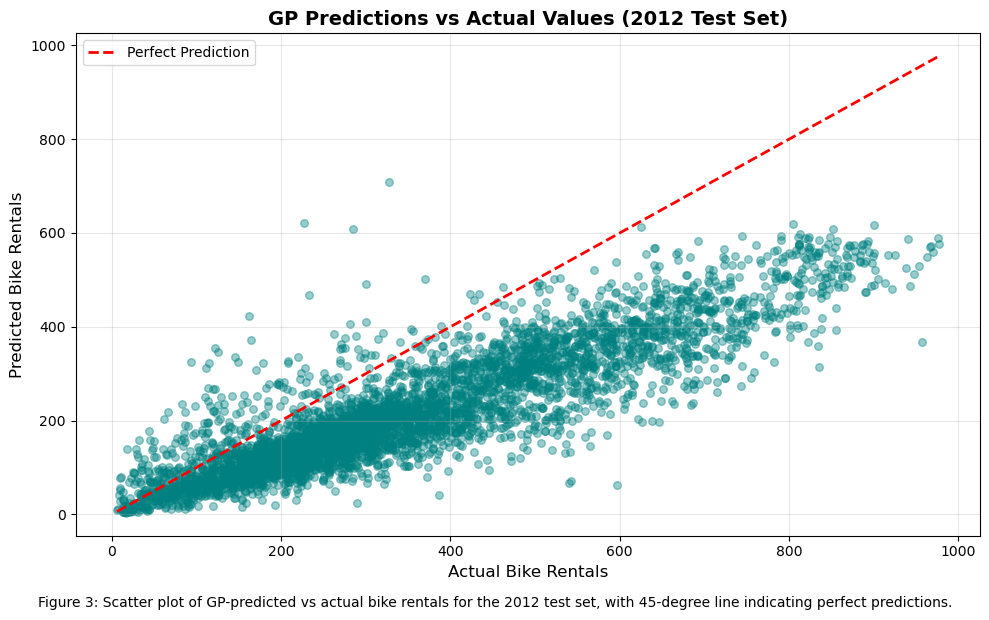

In [39]:
# Ensure weather_test is perfectly aligned with X_test_scaled (Year 2012)
weather_test = hour_filtered[hour_filtered['year'] == 1]['weather'].values

# Define masks for the entire test set
clear_mask = (weather_test == 1)
wet_mask = (weather_test > 1)

#Predictions vs Actual (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_original, alpha=0.4, s=30, color='teal')
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Bike Rentals', fontsize=12)
plt.ylabel('Predicted Bike Rentals', fontsize=12)
plt.title('GP Predictions vs Actual Values (2012 Test Set)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.figtext(
    0.5,
    -0.02,
    "Figure 3: Scatter plot of GP-predicted vs actual bike rentals for the 2012 test set, with 45-degree line indicating perfect predictions.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


According to the plot, the GP model also depicts limited predictive performance with most points clustering around the lower end of the perfect prediction line (45-degree red dashed line), while there is noticeable spread indicating prediction errors. The model seems to underpredict high-demand periods with above 400 rentals, as seen by points falling below the diagonal line in the upper right region. The systematic deviation at higher rental values suggests the model may struggle to fully capture peak demand conditions. This aligns with the moderate R-squared of 0.284 observed in the evaluation metrics.


/var/folders/mp/t9z5m_3909326cqbm3rdh_440000gn/T/ipykernel_39281/3955275304.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([y_std[clear_mask], y_std[wet_mask]],


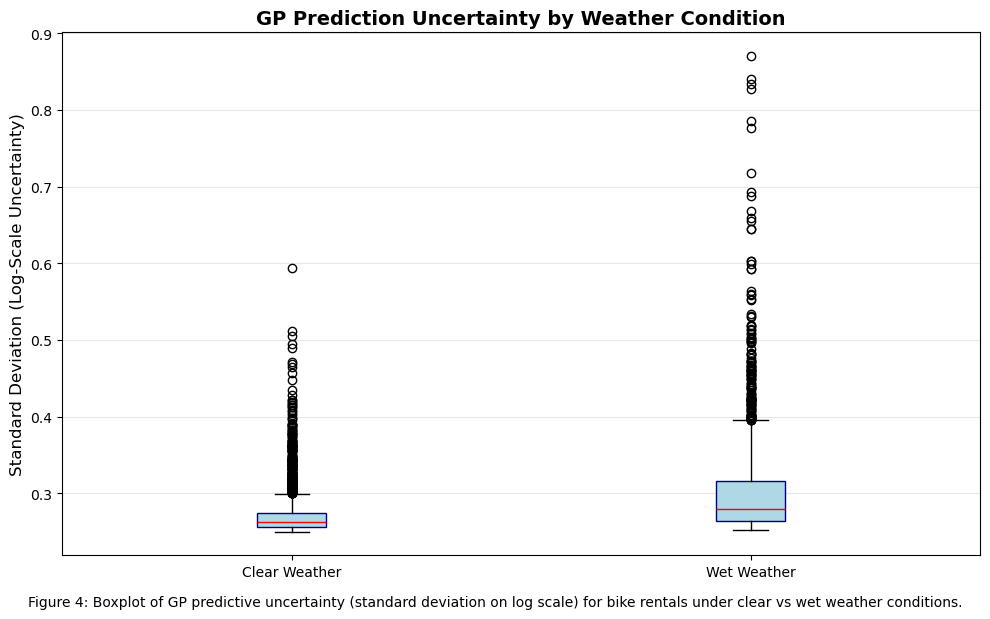

In [40]:
# Uncertainty Comparison by Weather (Boxplot)
plt.figure(figsize=(10, 6))
plt.boxplot([y_std[clear_mask], y_std[wet_mask]], 
            labels=['Clear Weather', 'Wet Weather'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='navy'),
            medianprops=dict(color='red'))
plt.ylabel('Standard Deviation (Log-Scale Uncertainty)', fontsize=12)
plt.title('GP Prediction Uncertainty by Weather Condition', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.figtext(
    0.5,
    -0.02,
    "Figure 4: Boxplot of GP predictive uncertainty (standard deviation on log scale) for bike rentals under clear vs wet weather conditions.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

The boxplot above shows that during wet conditions, the GP model captures higher prediction uncertainty with both the median and interquartile range noticeably higher compared to clear weather. The wet-weather box is also more variable and contains more outliers at higher values of uncertainty, as high as about 0.87, while clear-weather predictions stay more consistently confident with a tighter distribution around 0.27. This plotting partially answers research question, where a Gaussian Process appropriately quantifies the increased forecast unreliability during adverse weather. The demand would turn  more volatile and hard to predict duirng the unpleasant weather days.

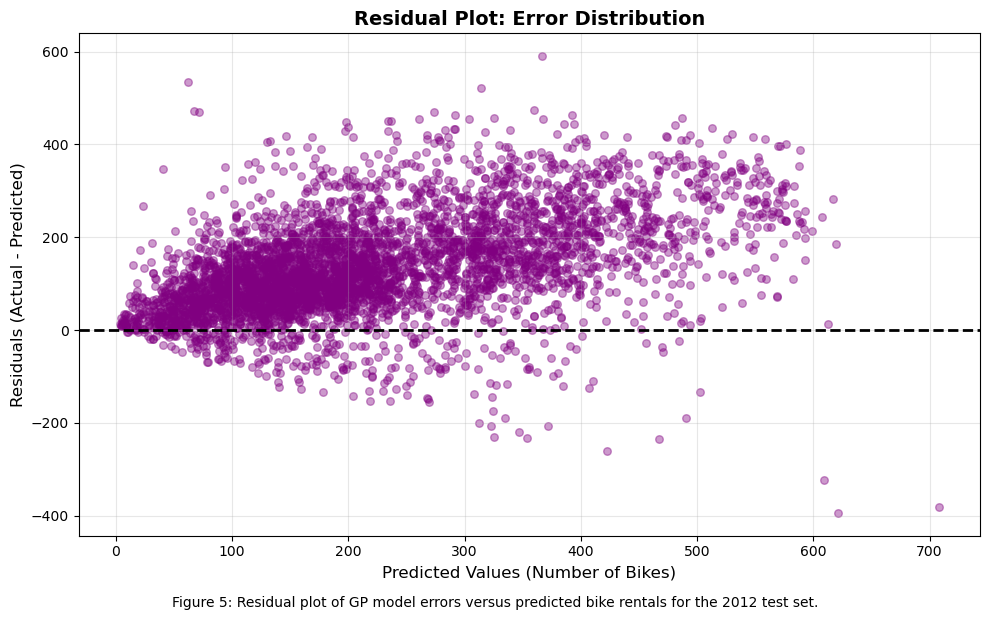

In [41]:
# Residuals Plot
residuals = y_test_original - y_pred_original
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_original, residuals, alpha=0.4, color='purple', s=30)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values (Number of Bikes)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot: Error Distribution', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.figtext(
    0.5,
    -0.02,
    "Figure 5: Residual plot of GP model errors versus predicted bike rentals for the 2012 test set.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


Figure 5 illustrates the errors, which are reasonably centered around zero with a roughly symmetric distribution, though there is a spread of residuals increases with predicted values. The model shows a slight tendency toward positive residuals (underprediction) at higher predicted values, which aligns with the observation from the scatter plot that the GP struggles to fully capture peak demand conditions. 

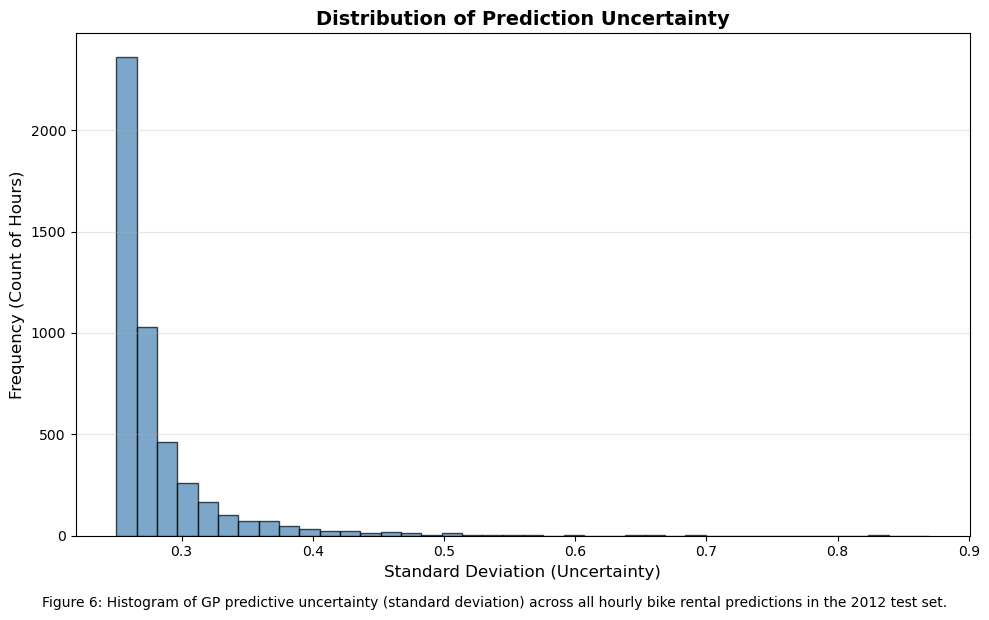

In [42]:
# Uncertainty Distribution (Histogram)
plt.figure(figsize=(10, 6))
plt.hist(y_std, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Standard Deviation (Uncertainty)', fontsize=12)
plt.ylabel('Frequency (Count of Hours)', fontsize=12)
plt.title('Distribution of Prediction Uncertainty', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.figtext(
    0.5,
    -0.02,
    "Figure 6: Histogram of GP predictive uncertainty (standard deviation) across all hourly bike rental predictions in the 2012 test set.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


As per the histogram above, the distribution of prediction uncertainty is heavily right-skewed, with the majority of predictions (over 2,300 hours) having relatively low uncertainty concentrated around 0.25-0.27 standard deviation. However, the long tail extending to 0.9 indicates that certain hours experience substantially higher uncertainty.

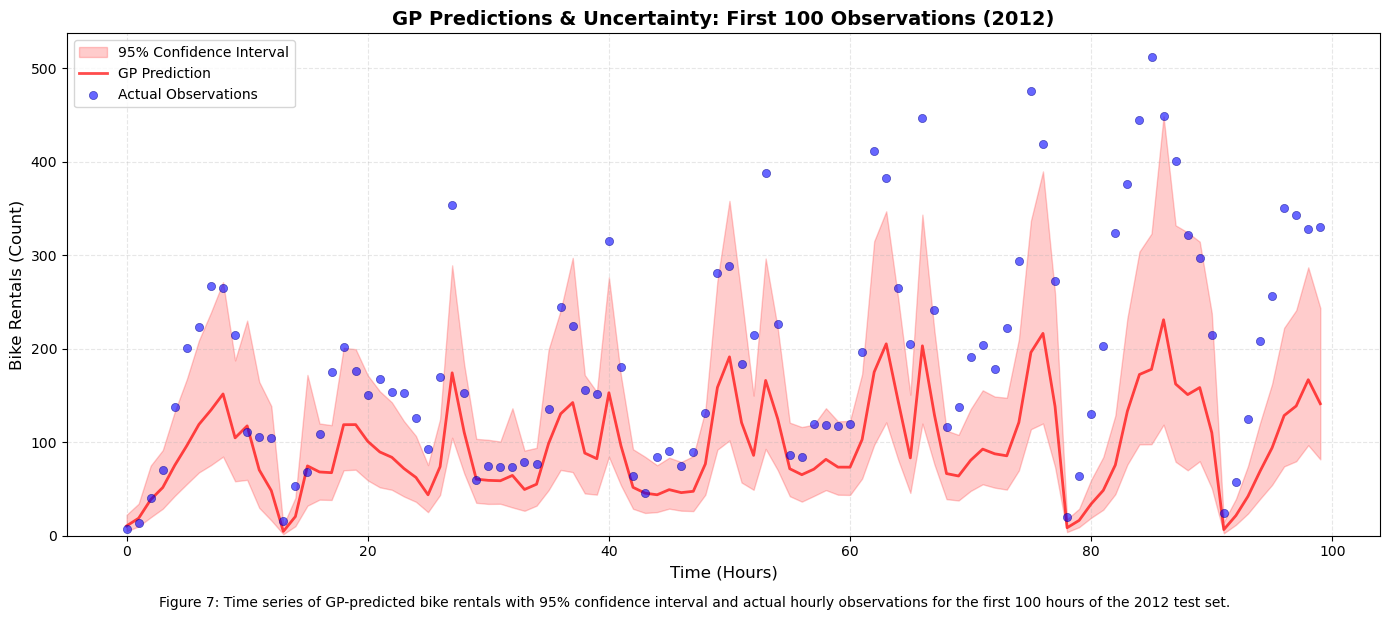

In [48]:
# first 100 hours of 2012 test set
sample_size = 100
x_axis = np.arange(sample_size)

plt.figure(figsize=(14, 6))


plt.fill_between(x_axis, 
                 y_lower[:sample_size], 
                 y_upper[:sample_size], 
                 alpha=0.2, color='red', label='95% Confidence Interval')


plt.plot(x_axis, y_pred_original[:sample_size], 'r-', 
         label='GP Prediction', linewidth=2, alpha=0.7)


plt.scatter(x_axis, y_test_original[:sample_size], 
            c='blue', s=35, alpha=0.6, edgecolors='darkblue', 
            linewidth=0.5, label='Actual Observations', zorder=5)


plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Bike Rentals (Count)', fontsize=12)
plt.title('GP Predictions & Uncertainty: First 100 Observations (2012)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(bottom=0)

plt.figtext(
    0.5,
    -0.02,
    "Figure 7: Time series of GP-predicted bike rentals with 95% confidence interval and actual hourly observations for the first 100 hours of the 2012 test set.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.savefig('gp_time_series_uncertainty.png')
plt.show()


In the graph above, the GP model successfully captures the cyclical fluctuations in bike rental demand across the first 100 hours of 2012. The 95% confidence intervals (red shaded regions) appropriately widen and narrow based on prediction certainty, with wider bands during periods of high volatility demonstrating the model's adaptive uncertainty quantification. Most actual observations (blue points) fall within the confidence intervals, indicating uncertainty estimates, though some outliers, particularly during peak demand periods, fall outside the bands, consistent with the model's tendency to underpredict extreme values.


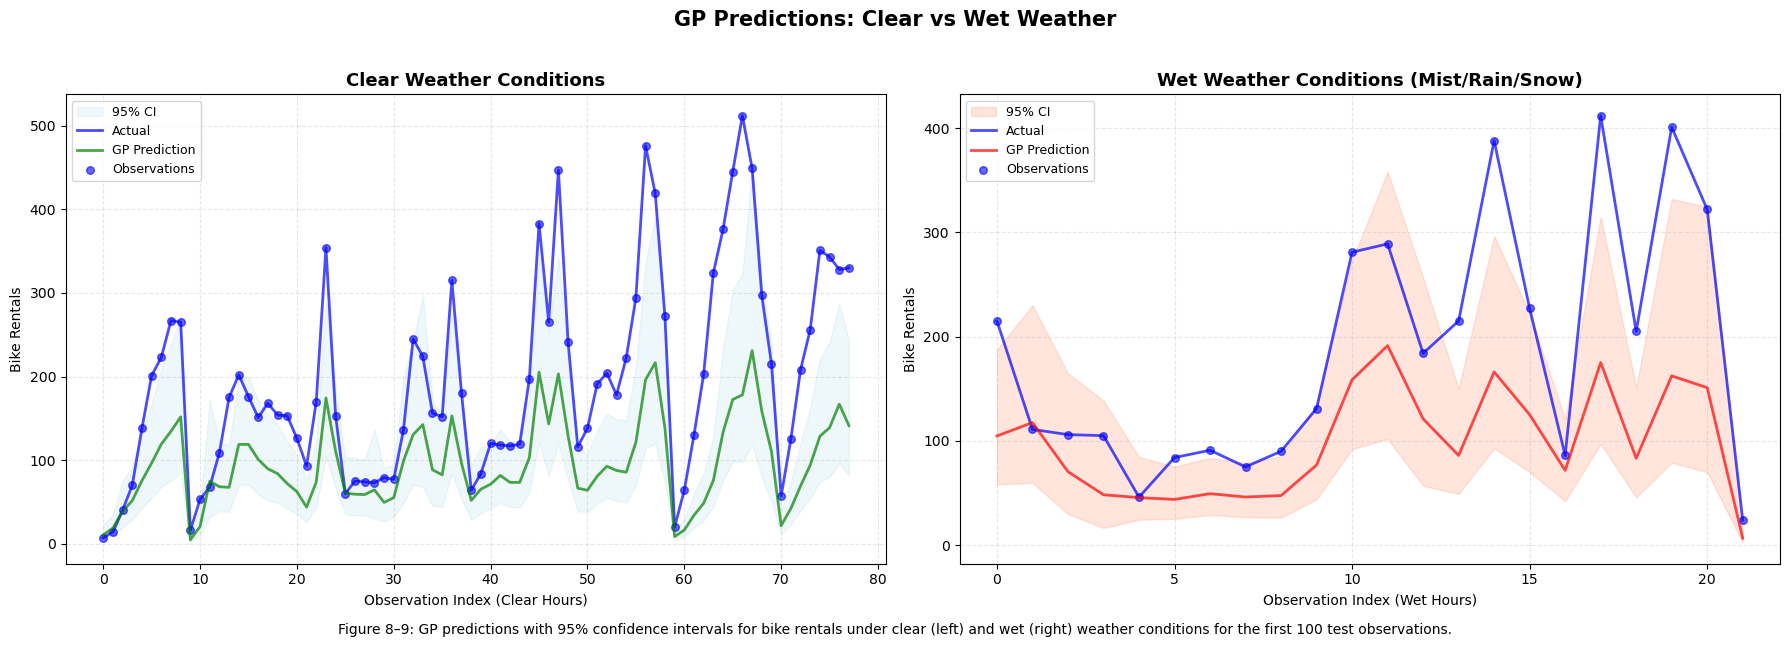

In [49]:

sample_size = 100

weather_test_sample = hour_filtered[hour_filtered['year'] == 1]['weather'].values[:sample_size]

clear_mask = (weather_test_sample == 1)
wet_mask = (weather_test_sample > 1)

y_act_sample = y_test_original[:sample_size]
y_pred_sample = y_pred_original[:sample_size]
y_low_sample = y_lower[:sample_size]
y_high_sample = y_upper[:sample_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Clear weather plot
if np.any(clear_mask):
    x_clear = np.arange(np.sum(clear_mask))
    ax1.fill_between(x_clear, y_low_sample[clear_mask], y_high_sample[clear_mask],
                     alpha=0.2, color='lightblue', label='95% CI')
    ax1.plot(x_clear, y_act_sample[clear_mask], 'b-', label='Actual', linewidth=2, alpha=0.7)
    ax1.plot(x_clear, y_pred_sample[clear_mask], 'g-', label='GP Prediction', linewidth=2, alpha=0.7)
    ax1.scatter(x_clear, y_act_sample[clear_mask], c='blue', s=30, alpha=0.6, label='Observations')

ax1.set_xlabel('Observation Index (Clear Hours)')
ax1.set_ylabel('Bike Rentals')
ax1.set_title('Clear Weather Conditions', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3, linestyle='--')

# Wet weather plot
if np.any(wet_mask):
    x_wet = np.arange(np.sum(wet_mask))
    ax2.fill_between(x_wet, y_low_sample[wet_mask], y_high_sample[wet_mask],
                     alpha=0.2, color='coral', label='95% CI')
    ax2.plot(x_wet, y_act_sample[wet_mask], 'b-', label='Actual', linewidth=2, alpha=0.7)
    ax2.plot(x_wet, y_pred_sample[wet_mask], 'r-', label='GP Prediction', linewidth=2, alpha=0.7)
    ax2.scatter(x_wet, y_act_sample[wet_mask], c='blue', s=30, alpha=0.6, label='Observations')

ax2.set_xlabel('Observation Index (Wet Hours)')
ax2.set_ylabel('Bike Rentals')
ax2.set_title('Wet Weather Conditions (Mist/Rain/Snow)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, linestyle='--')

plt.suptitle('GP Predictions: Clear vs Wet Weather', fontsize=15, fontweight='bold', y=1.02)

fig.text(
    0.5,
    -0.02,
    "Figure 8–9: GP predictions with 95% confidence intervals for bike rentals under clear (left) and wet (right) weather conditions for the first 100 test observations.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


The graphs above shows markedly different uncertainty characteristics across weather conditions. Under clear weather (left panel), the model produces relatively narrow confidence intervals with the GP predictions (green line) closely tracking actual demand patterns across 78 clear-weather hours. In contrast, the wet weather conditions (right panel) exhibit substantially wider confidence bands (coral shaded region), particularly during mid-range demand periods, reflecting the model's appropriate acknowledgment of increased forecast uncertainty when adverse weather makes bike rental behavior less predictable.

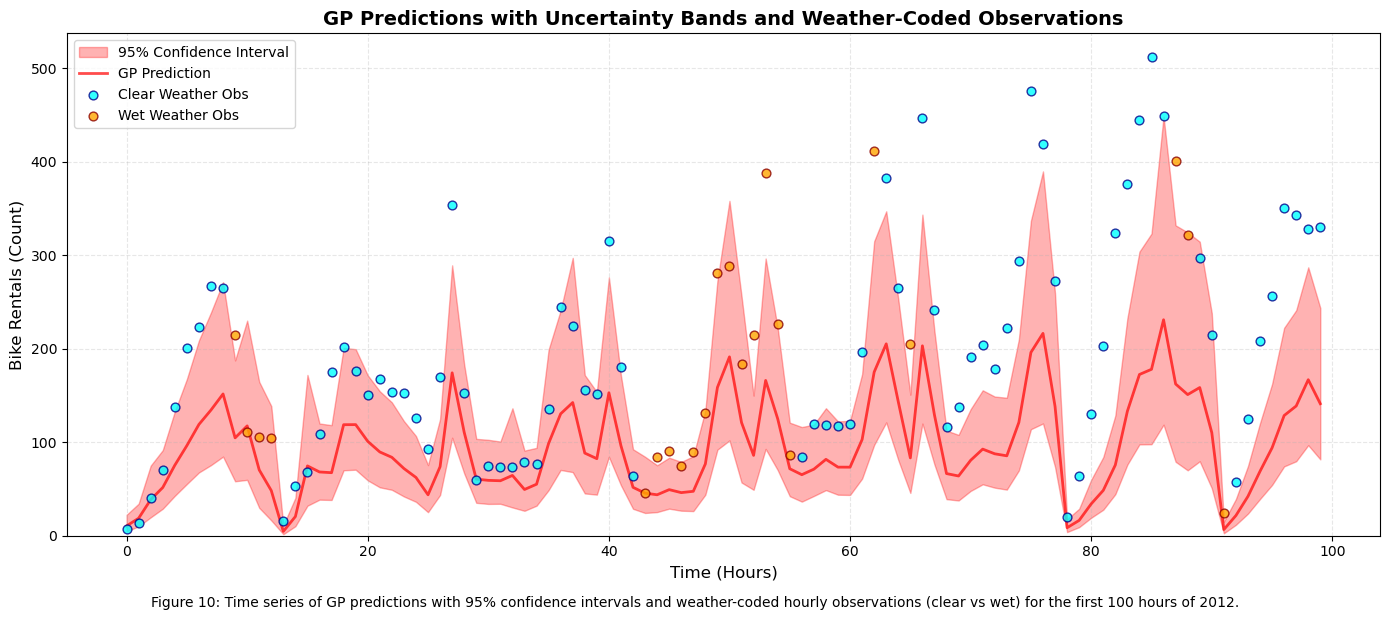

In [50]:
# Define sample size (first 100 hours of 2012)
sample_size = 100
x_axis = np.arange(sample_size)

# Extract weather labels specifically for the 2012 test set
# Ensures alignment with y_test_original and the GP predictions
weather_test_sample = hour_filtered[hour_filtered['year'] == 1]['weather'].values[:sample_size]

# Create masks for clear and wet weather
clear_mask = (weather_test_sample == 1)
wet_mask = (weather_test_sample > 1)

# Slice result arrays
y_act_sample = np.array(y_test_original[:sample_size])
y_pred_sample = np.array(y_pred_original[:sample_size])
y_low_sample = np.array(y_lower[:sample_size])
y_high_sample = np.array(y_upper[:sample_size])

plt.figure(figsize=(14, 6))

# Plot uncertainty band (Background)
plt.fill_between(x_axis, 
                 y_low_sample, 
                 y_high_sample, 
                 alpha=0.3, color='red', label='95% Confidence Interval')

# Plot GP Prediction line
plt.plot(x_axis, y_pred_sample, 'r-', label='GP Prediction', linewidth=2, alpha=0.7)

# Plot observations with weather-based colors
# Clear weather observations (Cyan)
plt.scatter(x_axis[clear_mask], y_act_sample[clear_mask], 
            c='cyan', s=40, alpha=0.8, edgecolors='darkblue', 
            linewidth=1, label='Clear Weather Obs', zorder=5)

# Wet weather observations (Orange)
plt.scatter(x_axis[wet_mask], y_act_sample[wet_mask], 
            c='orange', s=40, alpha=0.8, edgecolors='darkred', 
            linewidth=1, label='Wet Weather Obs', zorder=5)

plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Bike Rentals (Count)', fontsize=12)
plt.title('GP Predictions with Uncertainty Bands and Weather-Coded Observations', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='best')
plt.grid(alpha=0.3, linestyle='--')
plt.ylim(bottom=0)

plt.figtext(
    0.5,
    -0.02,
    "Figure 10: Time series of GP predictions with 95% confidence intervals and weather-coded hourly observations (clear vs wet) for the first 100 hours of 2012.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()


Figure 10 demonstrates prediction challenges across both weather conditions, with considerable deviations between predicted values (red line) and actual observations for both clear (cyan) and wet (orange) weather hours. While the confidence intervals appropriately widen during wet weather periods, many observations from both weather regimes fall outside or near the edges of the 95% bands, indicating systematic underprediction particularly during high-demand hours regardless of weather condition. This pattern suggests that while the model manages to quantify the differential uncertainty between weather types, the overall predictive accuracy remains limited across both clear and adverse weather scenarios, as evidenced by the moderate R-squared of only 0.284.


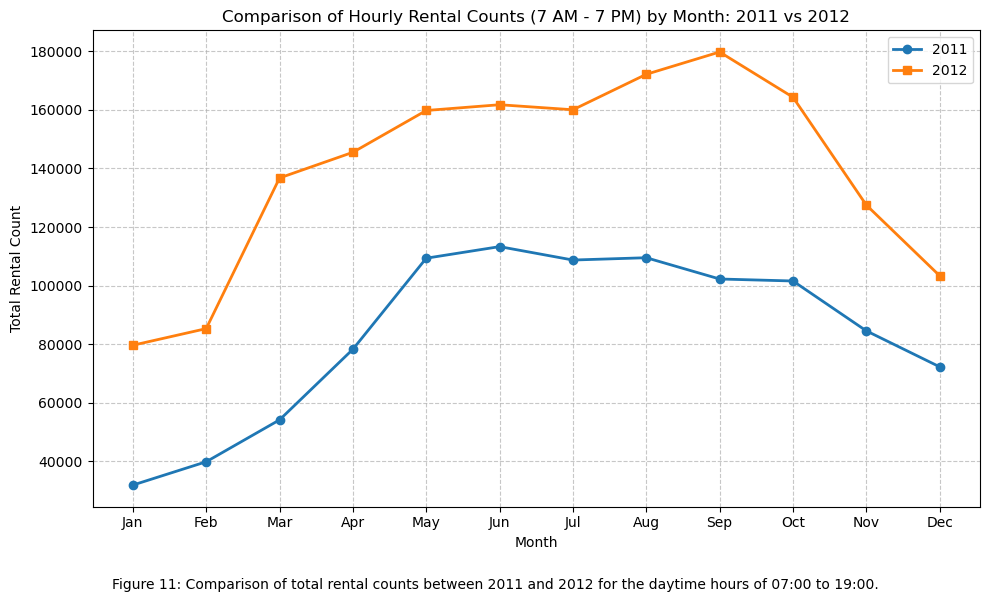

In [51]:
# Load the dataset
df = pd.read_csv('hour.csv')

# Filter for hours 7 AM to 7 PM (7 through 19 inclusive)
df_filtered = df[(df['hr'] >= 7) & (df['hr'] <= 19)].copy()

# Map yr (0, 1) to the actual years (2011, 2012)
df_filtered['year_label'] = df_filtered['yr'].map({0: 2011, 1: 2012})

# Aggregate rental counts by year and month
monthly_counts = df_filtered.groupby(['year_label', 'mnth'])['cnt'].sum().reset_index()

# Pivot the data for comparison
pivot_df = monthly_counts.pivot(index='mnth', columns='year_label', values='cnt')

# Create the visualization
plt.figure(figsize=(10, 6))
plt.plot(pivot_df.index, pivot_df[2011], marker='o', label='2011', linewidth=2)
plt.plot(pivot_df.index, pivot_df[2012], marker='s', label='2012', linewidth=2)

# Chart formatting
plt.title('Comparison of Hourly Rental Counts (7 AM - 7 PM) by Month: 2011 vs 2012')
plt.xlabel('Month')
plt.ylabel('Total Rental Count')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

caption = "Figure 11: Comparison of total rental counts between 2011 and 2012 for the daytime hours of 07:00 to 19:00."
plt.figtext(0.5, 0.01, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('rental_comparison_2011_2012.png')

Returning to this graph, however, only looking at the daytime hours, it is now feasible to conclude that the increase in bike rental demand over two years has affected the performance of the Gaussian Process model. Bike rental demand during daytime hours (7 AM to 7 PM) increased substantially in 2012 compared to 2011 across all months. The 2012 rental counts (orange line) consistently exceed 2011 levels (blue line) by approximately 50-60%. This year-over-year growth in the bike-sharing system presents a challenge for the train-test split methodology. The GP model trained exclusively on 2011 data must predict 2012 demand that operates at a fundamentally higher baseline level. This structural shift in demand magnitude likely contributes to the model's moderate R-squared of 0.284 and systematic underprediction at higher rental counts, as the training data may not fully capture the scale of operations in the test year.

This study looked at how well Gaussian Process (GP) regression can forecast hourly bike-sharing demand. The GP model had an RMSE of 169.96 bikes and an $R^2$ of 0.284. In predictive modeling, an $R^2$ below 0.3 is very low indicates bad performance. This means the model does not explain about 72% of the variance in the 2012 test set. While the model captures general daily cycles, it does not perform well as a point forecaster in its current state. 

The main reason for this poor performance is the potential structural change identified by the train-test split over time. Bike rental demand increased significantly overall and specifically rose during daytime hours (7 AM to 7 PM) by about 50-60% in 2012 compared to 2011. Since the model was trained only on 2011 data, it did not account for the much higher baseline of the following year. As a result, the GP consistently underpredicted demand during peak times, trying to apply 2011 scales to a much larger 2012 system.

Despite its weak predictive accuracy, the model showed the capability of Gaussian Processes in measuring uncertainty. The GP had 12.5% higher mean prediction uncertainty (standard deviation) during wet weather (0.305) than in clear weather (0.271). This increased uncertainty in bad weather comes from two main factors. First, rider behavior tends to be more unpredictable during rain or snow. Second, as seen in the dataset, there are many more "clear" days than "wet" days. In GP modeling, this lack of data points causes the model's confidence intervals to widen. 

The boxplot visualization showed wider confidence intervals during misty, rainy, or snowy conditions. This confirms the model’s ability to indicate when its predictions may be unreliable. While the model was struggling to give an accurate bike count during periods of rapid growth, its ability to distinguish between "reliable" and "unreliable" forecast conditions is valuable for managing operational risk. For bike-sharing administrators, knowing when a forecast is likely to be wrong during a storm can be just as crucial as the prediction itself. Future versions of this model should include year-over-year growth features or implement a more complex kernel that combines periodic components with a linear trend component. This could help the model adapt to the year-over-year growth of the bike-sharing system.


Finally, we recognize that reducing the number of observations to keep training times manageable likely hurt the model's predictive accuracy. However, due to the $O(N^3)$ complexity involved in inverting the Gaussian Process covariance matrix, training on the entire dataset was not feasible. The processing requirements exceeded what our local hardware could handle, making full matrix inversions within a reasonable timeframe impossible. 

Besides computational limitations, picking and fine-tuning the right kernel was a major challenge. We attempted to test different kernel combinations. However, the time-consuming nature of each training cycle greatly limited the hyperparameter tuning process and finding the best kernel combination. This forced us to pick a commonly used kernel. We understood consequently, that we might need a more complex kernel to manage the rental growth, but the computational cost of optimizing such a model with our available resources kept us from achieving better results. 

# Conclusion

In conclusion, for our project we looked at whether Gaussian Process regression can effectively predict hourly bike-sharing demand while measuring uncertainty under different weather conditions. The GP model showed a low R-squared value of 0.284, with an RMSE of 169.96 and an MAE of 140.93. This weak predictive performance mainly stems from a noticeable change in the dataset, where demand in 2012 consistently surpassed that of 2011 by 50-60%. More importantly, the model displayed 12.5% higher prediction uncertainty during wet weather (mean standard deviation of 0.305) compared to clear weather (0.271). This indicates that GPs effectively recognize when forecasts are less trustworthy due to both weather variability and uncertainty stemming from limited wet-weather data points. The low R-squared value and consistent underprediction illustrate the limits of the training setup. Due to the $O(N^3)$ computational complexity of the GP framework, training on the complete dataset and conducting wide-ranging kernel optimization was too computationally expensive. This meant reducing the number of observations, which likely impeded the model's ability to capture the full extent of the growth in 2012. While the model successfully identifies cycles, its inability to explain almost 72% of the variance shows that the current setup is not a suitable for forecasting bike rentals accurately. Despite these predictive issues, the strength of the Gaussian Process lies in its uncertainty prediction capability. For managing bike-sharing operations, knowing when a forecast is likely to be incorrect is just as important as the prediction itself. Finally, considering our findings, Gaussian Process, especially in our setting, is more practical as a tool for quantifying uncertainty than as a precise forecaster for demand for bike sharing during the day under growth, as we found out out in the course of this project.

# Reference

[1] James, G., Witten, D., Hastie, T., Tibshirani, R. and Taylor, J., 2023. An Introduction to Statistical Learning: with Applications in Python. Cham: Springer Nature Switzerland AG.

[2] Lindholm, A., Wahlström, N., Lindsten, F. and Schön, T.B., 2022. Machine Learning: A First Course for Engineers and Scientists. Cambridge: Cambridge University Press.

[3] Fanaee-T, H. and Gama, J., 2013. Bike Sharing Dataset. [Dataset] UCI Machine Learning Repository. Available at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset [Accessed 12 Jan. 2026].

# AI Statement

In this project, AI tools such as OpenAI's ChatGPT, Grammarly and Perplexity were used for code fixing, syntax error explanations, as well as proof-checking the written paragraphs.